# Reconciliation Automation Engine

End-to-End Reconciliation Workflow Demo

In [1]:
import sys
import os

sys.path.append("../src")

from load_data import (load_source_file, load_target_file)

from normalize_data import (normalize_names, normalize_dates, normalize_amounts)

from compare_data import compare_records

from report_generator import generate_reports

from fuzzy_matcher import (calculate_similarity, is_probable_match)

# Load Data

In [2]:
source_df = load_source_file()

target_df = load_target_file()

print("Source Rows:", len(source_df))
print("Target Rows:", len(target_df))

Source Rows: 5
Target Rows: 5


In [3]:
source_df

,invoice_id,customer_name,invoice_date,amount
0,INV1001,ABHIRAM TK,06/01/2026,5000
1,INV1002,RAHUL MENON,06/01/2026,7500
2,INV1003,PRIYA SHARMA,06/01/2026,10000
3,INV1004,ARJUN KUMAR,06/01/2026,15000
4,INV1005,ANJALI NAIR,06/01/2026,20000


In [4]:
target_df

,invoice_id,customer_name,invoice_date,amount
0,INV1001,abhiram tk,2026-06-01,5000
1,INV1002,rahul menon,2026-06-01,7500
2,INV1003,priya sharma,2026-06-01,12000
3,INV1005,anjali menon,2026-06-01,20000
4,INV1006,vivek nair,2026-06-01,30000


# Normalize Data

In [5]:
source_df = normalize_names(source_df)
source_df = normalize_dates(source_df)
source_df = normalize_amounts(source_df)

target_df = normalize_names(target_df)
target_df = normalize_dates(target_df)
target_df = normalize_amounts(target_df)

In [6]:
source_df

,invoice_id,customer_name,invoice_date,amount
0,INV1001,abhiram tk,2026-06-01,5000.0
1,INV1002,rahul menon,2026-06-01,7500.0
2,INV1003,priya sharma,2026-06-01,10000.0
3,INV1004,arjun kumar,2026-06-01,15000.0
4,INV1005,anjali nair,2026-06-01,20000.0


In [7]:
target_df

,invoice_id,customer_name,invoice_date,amount
0,INV1001,abhiram tk,2026-06-01,5000.0
1,INV1002,rahul menon,2026-06-01,7500.0
2,INV1003,priya sharma,2026-06-01,12000.0
3,INV1005,anjali menon,2026-06-01,20000.0
4,INV1006,vivek nair,2026-06-01,30000.0


# Exact Comparison

In [8]:
results = compare_records(source_df, target_df)

results

[{'invoice_id': 'INV1001', 'status': 'MATCHED'},
 {'invoice_id': 'INV1002', 'status': 'MATCHED'},
 {'invoice_id': 'INV1003', 'status': 'MISMATCHED'},
 {'invoice_id': 'INV1004', 'status': 'MISSING'},
 {'invoice_id': 'INV1005', 'status': 'MISMATCHED'}]

In [9]:
import pandas as pd

comparison_df = pd.DataFrame(results)

comparison_df

,invoice_id,status
0,INV1001,MATCHED
1,INV1002,MATCHED
2,INV1003,MISMATCHED
3,INV1004,MISSING
4,INV1005,MISMATCHED


# Rapidfuzz Matching

In [10]:
name_1 = "abhiram tk"

name_2 = "abiram tk"

score = calculate_similarity(name_1, name_2)

print("Similarity Score:", score)

print("Probable Match:", is_probable_match(name_1, name_2))

Similarity Score: 94.73684210526316
Probable Match: True


# Generate Reports

In [11]:
generate_reports(results)

print("Reports Generated Successfully")

Reports Generated Successfully


# Mismatch Summary

In [13]:
summary = comparison_df["status"].value_counts()

summary.to_frame(name="Record Count")

,Record Count
status,
MATCHED,2
MISMATCHED,2
MISSING,1


# Analytics

In [17]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [18]:
from src.analytics import (generate_summary, save_summary, generate_chart)

In [19]:
summary_df = generate_summary(comparison_df)

summary_df

,Status,Count
0,MATCHED,2
1,MISMATCHED,2
2,MISSING,1


In [20]:
save_summary(summary_df)

generate_chart(summary_df)

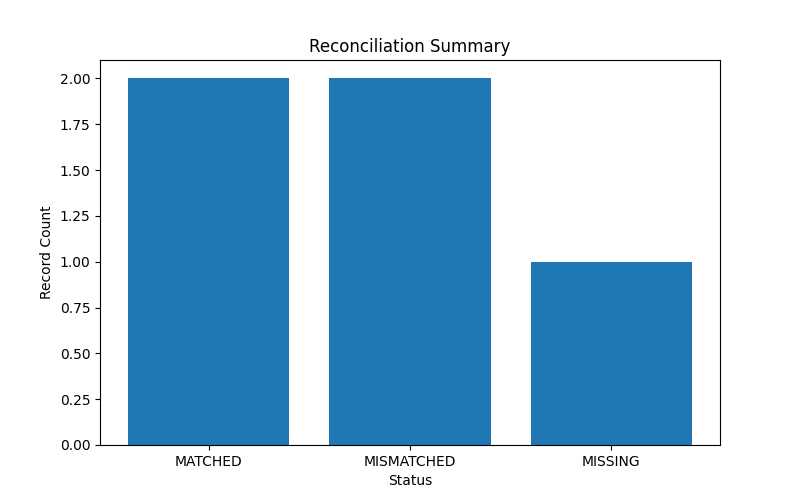

In [21]:
from IPython.display import Image

Image("../reports/reconciliation_summary.png")